In [2]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

In [3]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [4]:
print(X_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


In [5]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [6]:
y_train[0]

5

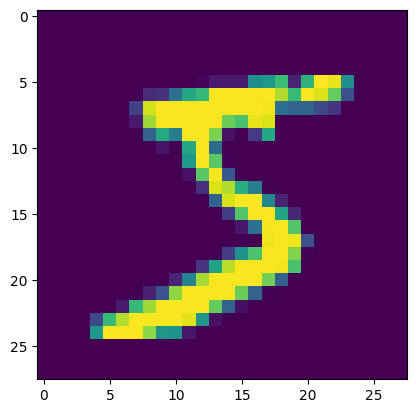

In [7]:
plt.imshow(X_train[0])

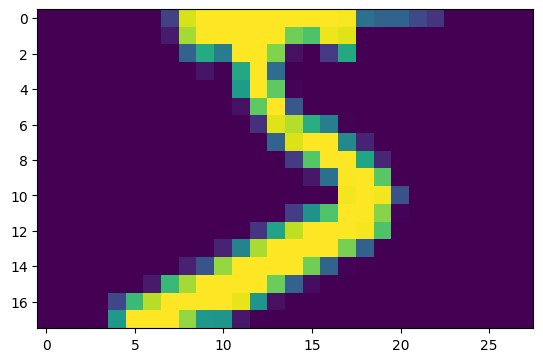

In [8]:
plt.imshow(X_train[0][4:25][3:23])

In [9]:
X_train = X_train/255
X_test = X_test/255

In [10]:
model = Sequential()

model.add(Flatten(input_shape = (28, 28)))
model.add(Dense(128, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(10, activation='softmax'))

In [11]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 32)                4128      
                                                                 
 dense_2 (Dense)             (None, 10)                330       
                                                                 
Total params: 104,938
Trainable params: 104,938
Non-trainable params: 0
_________________________________________________________________


In [12]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='Adam')

In [13]:
history = model.fit(X_train, y_train, epochs=25, validation_split=0.2)

Epoch 1/25
1500/1500 [==============================] - 8s 3ms/step - loss: 0.2951 - val_loss: 0.1404
Epoch 2/25
1500/1500 [==============================] - 4s 3ms/step - loss: 0.1185 - val_loss: 0.1147
Epoch 3/25
1500/1500 [==============================] - 4s 3ms/step - loss: 0.0816 - val_loss: 0.1095
Epoch 4/25
1500/1500 [==============================] - 4s 3ms/step - loss: 0.0621 - val_loss: 0.0890
Epoch 5/25
1500/1500 [==============================] - 4s 3ms/step - loss: 0.0485 - val_loss: 0.0956
Epoch 6/25
1500/1500 [==============================] - 4s 3ms/step - loss: 0.0369 - val_loss: 0.1074
Epoch 7/25
1500/1500 [==============================] - 4s 3ms/step - loss: 0.0304 - val_loss: 0.0999
Epoch 8/25
1500/1500 [==============================] - 4s 3ms/step - loss: 0.0243 - val_loss: 0.0985
Epoch 9/25
1500/1500 [==============================] - 8s 5ms/step - loss: 0.0222 - val_loss: 0.1077
Epoch 10/25
1500/1500 [==============================] - 7s 5ms/step - loss: 0.019

In [14]:
y_prob = model.predict(X_test)
print(y_prob)

313/313 [==============================] - 1s 3ms/step
[[9.2263943e-16 2.9369518e-10 2.5489485e-14 ... 1.0000000e+00
  2.1727309e-13 3.8289437e-14]
 [7.1213416e-16 2.5811481e-08 1.0000000e+00 ... 6.5149346e-20
  3.0620244e-14 1.2763236e-31]
 [2.7503009e-12 9.9999964e-01 5.7120950e-11 ... 1.8516450e-07
  1.4650387e-07 1.4084031e-15]
 ...
 [3.5596409e-25 6.0465530e-22 1.6731473e-21 ... 5.1146728e-17
  1.5114887e-12 2.5003510e-08]
 [1.6552017e-20 1.7053108e-25 1.2997265e-22 ... 6.8666539e-24
  3.0260898e-11 2.5534577e-19]
 [4.6522492e-13 7.2695670e-21 9.0597926e-22 ... 1.1889445e-21
  7.0375890e-18 2.8693703e-22]]


In [15]:
y_prob.argmax(axis=1)

array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

In [16]:
y_prob[0]

array([9.2263943e-16, 2.9369518e-10, 2.5489485e-14, 6.6302602e-14,
       3.0009648e-23, 1.3682384e-19, 3.8726195e-23, 1.0000000e+00,
       2.1727309e-13, 3.8289437e-14], dtype=float32)

In [17]:
y_pred = y_prob.argmax(axis=1)
accuracy_score(y_test, y_pred)

0.9763

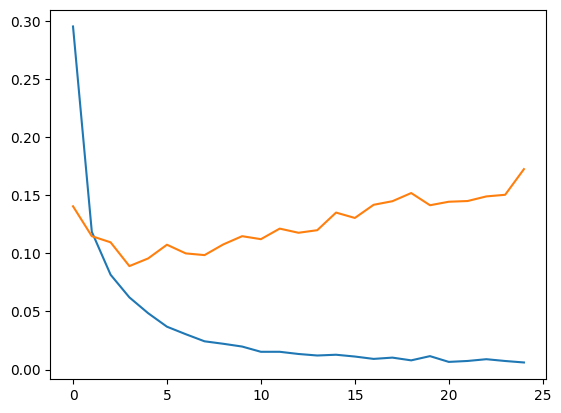

In [23]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])